In [ ]:
# Análise Exploratória — Indicador Criança Alfabetizada

**Objetivo desta análise:** entender a estrutura, qualidade e distribuição da base
`features_alunos_ml` (camada Gold, Fase 2) antes de tomar qualquer decisão de
modelagem.

**Contexto da base:** cada linha é um aluno avaliado no 2º ano do Ensino
Fundamental, com proficiência no Saeb, contexto do seu município (taxa de
alfabetização agregada, meta vigente) e o rótulo `label_alfabetizado`
(1 = proficiência ≥ 743 pontos, 0 = caso contrário).

In [2]:
import pandas as pd

pd.set_option("display.max_columns", None)

df = pd.read_parquet("../data/raw/features_alunos_ml.parquet")
df.shape

(3867999, 15)

In [ ]:
## Estrutura e tipos de dados

Antes de qualquer análise de conteúdo, precisamos saber **como** cada coluna
está tipada — isso já revela problemas em potencial (ex.: uma coluna numérica
armazenada como texto, ou um identificador sendo tratado como número).

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3867999 entries, 0 to 3867998
Data columns (total 15 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   id_aluno                          object 
 1   ano                               int64  
 2   id_municipio                      object 
 3   nome                              object 
 4   sigla_uf                          object 
 5   nome_regiao                       object 
 6   rede                              object 
 7   rede_label                        object 
 8   serie                             object 
 9   proficiencia                      float64
 10  peso_aluno                        float64
 11  presenca                          object 
 12  taxa_alfabetizacao_municipio      float64
 13  meta_alfabetizacao_municipio_ano  float64
 14  label_alfabetizado                int32  
dtypes: float64(4), int32(1), int64(1), object(9)
memory usage: 427.9+ MB


In [ ]:
## Valores ausentes

Aqui medimos, por coluna, quantos valores estão ausentes em número absoluto e
em percentual do total. Isso vai definir, coluna por coluna, se a estratégia
certa é imputar, descartar a linha, ou descartar a coluna inteira (uma coluna
90% vazia não deveria ser imputada — deveria ser removida).

In [4]:
faltantes = df.isnull().sum().sort_values(ascending=False)
faltantes_pct = (faltantes / len(df) * 100).round(2)
pd.DataFrame({"faltantes": faltantes, "pct": faltantes_pct})

,faltantes,pct
meta_alfabetizacao_municipio_ano,1868546,48.31
proficiencia,513338,13.27
peso_aluno,513338,13.27
taxa_alfabetizacao_municipio,172460,4.46
id_aluno,0,0.00
ano,0,0.00
id_municipio,0,0.00
nome,0,0.00
sigla_uf,0,0.00
nome_regiao,0,0.00


In [5]:
df["label_alfabetizado"].value_counts()

label_alfabetizado
1    1984546
0    1883453
Name: count, dtype: int64

In [6]:
# Cruza com a regra oficial: quem tem proficiência >= 743 deveria ter label=1
pd.crosstab(df["proficiencia"] >= 743, df["label_alfabetizado"])

label_alfabetizado,0,1
proficiencia,,
False,1883453,0
True,0,1984546


In [ ]:
### Conclusão final e decisão de escopo

Com o rótulo corrigido, o padrão faz sentido: **100% dos alunos ausentes**
têm `label_alfabetizado = 0` — coerente com a própria definição da fonte
(não avaliado não pode ser considerado alfabetizado). Entre os alunos
**presentes**, a divisão é real: 59,14% alfabetizados vs. 40,86% não
alfabetizados — sem desbalanceamento severo, mas longe de ser 50/50.

**Decisão de escopo:** vamos restringir a modelagem aos alunos com
`presenca == 1`. Incluir os ausentes ensinaria o modelo a reaprender uma
regra determinística da própria fonte (ausência → não alfabetizado), não
um padrão preditivo real a partir de variáveis educacionais, territoriais
e socioeconômicas — que é exatamente o que o desafio pede. Essa é também a
primeira decisão concreta de **tratamento de data leakage** do projeto:
excluir uma variável (`presenca`) cujo valor 0 determina o rótulo por
construção, não por relação causal a ser aprendida.

In [ ]:
## Filtrando o escopo de modelagem

Aplicamos a decisão anterior: só alunos com `presenca == 1` entram no
conjunto que vai alimentar o modelo. Criamos `df_model` como uma cópia
separada — mantemos `df` intacto (com todo mundo) caso precisemos voltar
a ele pra alguma análise de contexto mais ampla.

In [6]:
df_model = df[df["presenca"] == 1].copy()
print("Linhas antes:", len(df))
print("Linhas depois do filtro:", len(df_model))
df_model["label_alfabetizado"].value_counts(normalize=True).round(4)

Linhas antes: 3867999
Linhas depois do filtro: 0


Series([], Name: proportion, dtype: float64)

In [7]:
df_model = df[df["presenca"] == "1"].copy()
print("Linhas antes:", len(df))
print("Linhas depois do filtro:", len(df_model))
df_model["label_alfabetizado"].value_counts(normalize=True).round(4)

Linhas antes: 3867999
Linhas depois do filtro: 3355846


label_alfabetizado
1    0.5914
0    0.4086
Name: proportion, dtype: float64

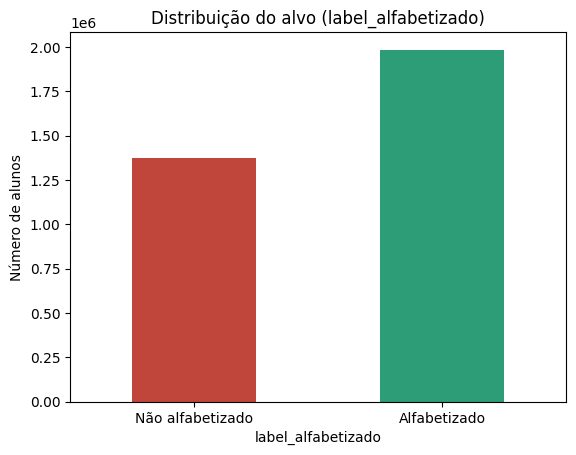

In [8]:
import matplotlib.pyplot as plt

contagem = df_model["label_alfabetizado"].value_counts().sort_index()
contagem.plot(kind="bar", color=["#C0453A", "#2D9D78"])
plt.xticks([0, 1], ["Não alfabetizado", "Alfabetizado"], rotation=0)
plt.ylabel("Número de alunos")
plt.title("Distribuição do alvo (label_alfabetizado)")
plt.show()

In [ ]:
## Investigação: `taxa_alfabetizacao_municipio` é uma fonte de data leakage?

Essa coluna é uma média agregada por (ano, município), calculada a partir
dos mesmos alunos que estamos tentando classificar — incluindo, para cada
linha, o próprio aluno daquela linha. Isso é diferente do vazamento do
`presenca`/`proficiencia` (que é direto e determinístico): aqui o risco
depende do **tamanho da amostra** de cada município. Num município com
3.000 alunos avaliados, o resultado de 1 aluno é irrelevante pra média. Num
município com 5 alunos avaliados, o resultado de 1 aluno pode mudar a média
em até 20 pontos percentuais — a "informação do território" vira, na
prática, quase uma paráfrase do próprio rótulo.

Vamos quantificar quantos municípios têm amostras pequenas antes de decidir
o que fazer.

In [9]:
alunos_por_municipio = (
    df_model.groupby(["ano", "id_municipio"])
    .size()
    .reset_index(name="n_alunos_avaliados")
)
alunos_por_municipio["n_alunos_avaliados"].describe()

count    10388.00000
mean       323.05025
std       1409.51545
min          7.00000
25%         54.00000
50%        112.00000
75%        249.00000
max      94385.00000
Name: n_alunos_avaliados, dtype: float64

In [14]:
# Quantos municípios (por ano) têm amostra pequena o suficiente pra um
# único aluno influenciar significativamente a média do próprio município?
for limite in [5, 10, 30, 50]:
    pct = (alunos_por_municipio["n_alunos_avaliados"] <= limite).mean() * 100
    print(f"Municípios com <= {limite} alunos avaliados: {pct:.1f}%")

Municípios com <= 5 alunos avaliados: 0.0%
Municípios com <= 10 alunos avaliados: 0.3%
Municípios com <= 30 alunos avaliados: 9.8%
Municípios com <= 50 alunos avaliados: 23.1%


In [ ]:
### Conclusão e decisão de tratamento

`taxa_alfabetizacao_municipio` é uma agregação legítima de contexto
territorial, mas ~10% dos municípios têm amostra pequena o suficiente
(≤30 alunos avaliados) para que o resultado de um único aluno influencie
de forma não desprezível a própria média usada para prevê-lo.

**Decisão:** em vez de descartar a variável (ela é exatamente o tipo de
dado territorial que o desafio pede para incluir), o split treino/teste
será feito **por município** (`GroupShuffleSplit`/`GroupKFold` por
`id_municipio`), não por aluno. Isso garante que nenhum município a## Distribuições territoriais e temporais

Olhamos rede, região, UF e ano — tanto pra entender a composição da base
quanto pra confirmar que não há uma classe dominando tanto a ponto de
inviabilizar alguma fatia da análise (ex.: uma região com poucos dados).pareça
simultaneamente em treino e teste — eliminando o caminho pelo qual esse
vazamento sutil poderia inflar artificialmente a métrica de generalização.
Essa decisão será aplicada na etapa de split.

In [10]:
print(df_model["ano"].value_counts())
print()
print(df_model["rede_label"].value_counts())
print()
print(df_model["nome_regiao"].value_counts())

ano
2024    1852788
2023    1503058
Name: count, dtype: int64

rede_label
Municipal    2983123
Estadual      372699
Privada           24
Name: count, dtype: int64

nome_regiao
Sudeste         1107474
Nordeste         969030
Sul              577249
Norte            368708
Centro-Oeste     333385
Name: count, dtype: int64


In [ ]:
## A lacuna de `meta_alfabetizacao_municipio_ano` é estrutural, não aleatória

Vimos no início que essa coluna falta em 48% das linhas. A hipótese é que
isso é 100% explicado pelo ano: só existem metas para 2024-2030, então
2023 (ano-base, antes do compromisso começar a valer) nunca deveria ter
meta. Confirmamos cruzando ausência da meta com o ano.

In [11]:
pd.crosstab(df_model["ano"], df_model["meta_alfabetizacao_municipio_ano"].isnull())

meta_alfabetizacao_municipio_ano,False,True
ano,,
2023,0,1503058
2024,1766270,86518


In [12]:
pd.crosstab(df_model[df_model["ano"] == 2024]["rede_label"], df_model[df_model["ano"] == 2024]["meta_alfabetizacao_municipio_ano"].isnull())

meta_alfabetizacao_municipio_ano,False,True
rede_label,,
Estadual,196833,44340
Municipal,1569413,42178
Privada,24,0


In [ ]:
### Conclusão: lacuna tem duas causas, ambas estruturais

1. **100% de 2023** falta meta — não existia meta antes de 2024 (esperado).
2. **~4,7% de 2024** falta meta (86.518 linhas) — não é explicado só pela
   rede do aluno (Estadual falta ~18%, Municipal falta ~2,6%, ambos > 0).
   A causa mais provável: o join é feito por `(ano, id_municipio)`, não por
   rede — então a lacuna real é de **municípios inteiros** sem meta
   municipal registrada naquele ano, afetando todos os alunos de lá,
   independente da própria rede.

**Decisão de tratamento:** essa é uma ausência estrutural, não aleatória,
mas também não é vazamento — é cobertura incompleta da fonte. Trataremos
com imputação (mediana) **mais uma coluna indicadora binária**
(`meta_ausente`), prática recomendada quando a própria ausência carrega
informação (município sem meta pode ser, em si, um sinal territorial
relevante) — em vez de simplesmente preencher e esconder o padrão.